# Property-Driven Training for Drug Dosing
## Presenter Notebook

> **Run the setup cell (▶) before the talk starts.** All other cells are either fast or have pre-computed outputs embedded.

---

### Presentation flow (30 min)

| # | Section | Type | Time |
|---|---------|------|------|
| 1 | The problem + simulation | live | 5 min |
| 2 | Vehicle spec walkthrough | live | 5 min |
| 3 | Baseline training + violation | live | 5 min |
| 4 | PDT + GradNorm (live demo) | live | 8 min |
| 5 | Full results + verification | pre-computed | 5 min |
| 6 | Discussion / exercises | — | 2 min |

---
## ▶ SETUP — Run this before the talk

> This cell takes ~2 minutes. Run it during intro slides.

In [2]:
!pip install vehicle-lang==0.24.1 idx2numpy tf2onnx -q
!rm -rf /content/drug-verification # Ensure a clean slate before cloning
# Explicitly change directory to /content for git clone robustness
!cd /content && git clone --branch rss https://github.com/lstrsrmn/drug-verification.git || echo "Git clone failed. Please check your internet connection or try again."

import sys, os

# Works on Colab (/content/drug-verification)
REPO = '/content/drug-verification'
if not os.path.isdir(REPO):
    raise FileNotFoundError(f"Cloned repository not found at {REPO}. Git clone command may have failed.")

# Change into the repository directory to run git commands
os.chdir(REPO)
# Write the simplified spec — overrides whatever was cloned
_VCL_SPEC = r"""
type UnnormalisedInputVector = Tensor Real [5]
type InputVector = Tensor Real [5]

conc = 0
temp = 1
wbc = 2
age = 3
weight = 4

type OutputVector= Tensor Real [1]

-- WARNING: these values are auto-updated by `update_vcl_scaler` in training.py
-- whenever the model is retrained via `pk train`. Do NOT edit them by hand.
-- They must match the StandardScaler fitted during training exactly; any
-- divergence means verification applies to different normalisation than the
-- exported ONNX model uses, silently invalidating the formal proof.
-- @dataset
meanScalingValues : UnnormalisedInputVector
meanScalingValues = [13.434305, 37.730657, 11.876029, 50.803191, 76.441588]

-- @dataset
standardDeviationValues : UnnormalisedInputVector
standardDeviationValues =  [7.3122337, 0.62039077, 2.5428018, 23.166708, 14.39579]

normalise : UnnormalisedInputVector -> InputVector
normalise x = foreach i .
  (x ! i - meanScalingValues ! i) / (standardDeviationValues ! i)

@network
pk : InputVector -> OutputVector

normpk : UnnormalisedInputVector -> OutputVector
normpk x = pk (normalise x)

@parameter
Ka : Real

@property
Ka_pos : Bool
Ka_pos = 0 < Ka

@parameter
Ke : Real

@property
Ke_pos : Bool
Ke_pos = 0 < Ke

@property
Ke_n_Ka : Bool
Ke_n_Ka = Ka != Ke

@parameter
Vd : Real

@property
Vd_pos : Bool
Vd_pos = 0 < Vd

@parameter
C_safe : Real

@property
C_safe_pos : Bool
C_safe_pos = 0 < C_safe

@parameter
ttd : Real

@property
ttd_pos : Bool
ttd_pos = 0 < ttd

@parameter
Ka_over : Real
-- e^-ka * (ln(ka/ke)/(ka-ke))

@parameter
Ka_under : Real

@parameter
Ke_over : Real
-- e^-ke * (ln(ka/ke)/(ka-ke))

@parameter
Ke_under : Real

@parameter
eps : Real

safeInput : UnnormalisedInputVector -> Bool
safeInput x =
  0    <= x ! conc   <= C_safe and
  36.5 <= x ! temp   <= 40     and
  7.5  <= x ! wbc    <= 20     and
  18   <= x ! age    <= 89     and
  50   <= x ! weight <= 100

safeOutput : UnnormalisedInputVector -> Bool
safeOutput x =
  let y = ((((normpk x) ! 0)*Ka) / (Vd*(Ka - Ke)))
  in if Ka < Ke
   then (x!conc) + y*(Ke_under - Ka_over) <= C_safe
   else (x!conc) + y*(Ke_over - Ka_under) <= C_safe

@property
safe : Bool
safe = forall x . safeInput x => safeOutput x

nonNegOutput : UnnormalisedInputVector -> Bool
nonNegOutput x = 0 <= (normpk x) ! 0

@property
nonNeg : Bool
nonNeg = forall x . safeInput x => nonNegOutput x"""
with open('pk.vcl', 'w') as _f:
    _f.write(_VCL_SPEC.lstrip())


# The 'drug_verification' package is expected within the 'src' subdirectory.
src_path = os.path.join(REPO, 'src')

# Install the package in editable mode to ensure it's properly recognized
print("\n--- Installing drug-verification package in editable mode ---")
!pip install -e .

# Re-inserting sys.path adjustment as pip install -e might not immediately update sys.path in Colab
sys.path.insert(0, src_path)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from drug_verification.simulation import simulate_cohort
from drug_verification.types import SimulationConfig
from drug_verification.training import (
    build_model, prepare_data, train_model,
    train_model_with_constraint, evaluate_model, update_vcl_scaler, export_onnx
)
from drug_verification.vehicle_loss import load_drug_verification_constraints
from drug_verification import constants as C

tf.random.set_seed(42)
np.random.seed(42)

# Pre-generate data and scalers
cfg = SimulationConfig(num_patients=50, timesteps=48, seed=42);
X, y = simulate_cohort(cfg, seed=42);
X_train, X_test, y_train, y_test, scaler, y_scaler = prepare_data(X, y, seed=42);
update_vcl_scaler(scaler, y_scaler=y_scaler, spec_path='pk.vcl');
y_mean = float(y_scaler.mean_[0]);
y_std  = float(y_scaler.scale_[0]);

def make_network_fn(model, y_mean, y_std, training=False):
    # training=False for diagnostic use; train_model_with_constraint uses training=True internally
    def network_fn(x):
        out = tf.reshape(model(tf.reshape(x, [1, -1]), training=training), [-1]);
        return out * y_std + y_mean;
    return network_fn;

# Pre-compile Vehicle constraint loss functions — slow (~60–120 s), so done in setup
print('Compiling Vehicle constraint loss functions (this takes ~1–2 minutes)...');
constraint_fns = load_drug_verification_constraints(
    spec_path='pk.vcl',
    properties=['safe'],
    mean=scaler.mean_,
    std_dev=scaler.scale_,
    parameters=C.DEFAULT_SPEC_PARAMS,
);

# Install Marabou (verification backend)
import glob, shutil

if 'google.colab' in sys.modules:
    _py = f'cp{sys.version_info.major}{sys.version_info.minor}'
    _wheel_versions = {'cp38', 'cp39', 'cp310', 'cp311'}
    if _py in _wheel_versions:
        MARABOU_WHL = (
            f'https://github.com/NeuralNetworkVerification/Marabou/releases/download/v2.0.0/'
            f'maraboupy-2.0.0-{_py}-{_py}-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
        )
        print(f'Installing maraboupy wheel for {_py}')
        !pip install -q {MARABOU_WHL}
    else:
        _repo = os.path.join(os.getcwd(), 'Marabou-src')
        _build = os.path.join(_repo, 'build')
        print(f'No maraboupy wheel for {_py} — building Marabou from source (this takes ~20 min)...')
        !apt-get install -qq cmake
        if not os.path.exists(_repo):
            !git clone -q --depth 1 --branch v2.0.0 https://github.com/NeuralNetworkVerification/Marabou.git {_repo}
        !cmake -S {_repo} -B {_build} -DCMAKE_BUILD_TYPE=Release -DBUILD_PYTHON=OFF -DRUN_UNIT_TEST=OFF -DRUN_REGRESS_TEST=OFF -DRUN_SYSTEM_TEST=OFF
        !cmake --build {_build} --target Marabou -j$(nproc) 2>&1 | tail -5

        _candidates = glob.glob(os.path.join(_build, '**', 'Marabou'), recursive=True)
        _binaries = [p for p in _candidates if os.path.isfile(p) and os.access(p, os.X_OK)]
        if not _binaries:
            raise RuntimeError(f'Marabou binary not found after build. Searched: {_build}')
        shutil.copy2(_binaries[0], '/usr/local/bin/Marabou')
        os.chmod('/usr/local/bin/Marabou', 0o755)
        print('Marabou installed to /usr/local/bin/Marabou')
else:
    print('Not in Colab — assuming vehicle and Marabou are already on PATH')

print('\n✓ Setup complete — ready to present');

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
chdir: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
Cloning into 'drug-verification'...
remote: Enumerating objects: 396, done.
remote: Counting objects: 100% (396/396), done.
remote: Compressing objects: 100% (221/221), done.
remote: Total 396 (delta 209), reused 326 (delta 146), pack-reused 0 (from 0)
Receiving objects: 100% (396/396), 3.83 MiB | 9.34 MiB/s, done.
Resolving deltas: 100% (209/209), done.
Working directory: /content/drug-verification

--- Installing drug-verification package in editable mode ---
Obtaining file:///content/drug-verification
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for drug-verification (pyproject.to

Updated pk.vcl with scaler values from this training run.
  meanScalingValues        = [2.6251915, 38.070456, 14.064574, 50.803191, 76.441588]
  standardDeviationValues  = [2.1576534, 0.49660919, 1.7778004, 23.166708, 14.39579]
  y_mean (dose scaler)     = 123.75367
  y_std  (dose scaler)     = 102.82006
Compiling Vehicle constraint loss functions (this takes ~1–2 minutes)...

✓ Setup complete — ready to present


---
## 1. The Problem: Safety vs Accuracy

We have a neural network that predicts drug doses.  
Low test error ≠ safe for all inputs.

**Five inputs:** plasma concentration, temperature, WBC, age, weight  
**One output:** recommended dose in mg  
**Safety limit:** C_safe = 30 µg/mL — above this, the drug is toxic

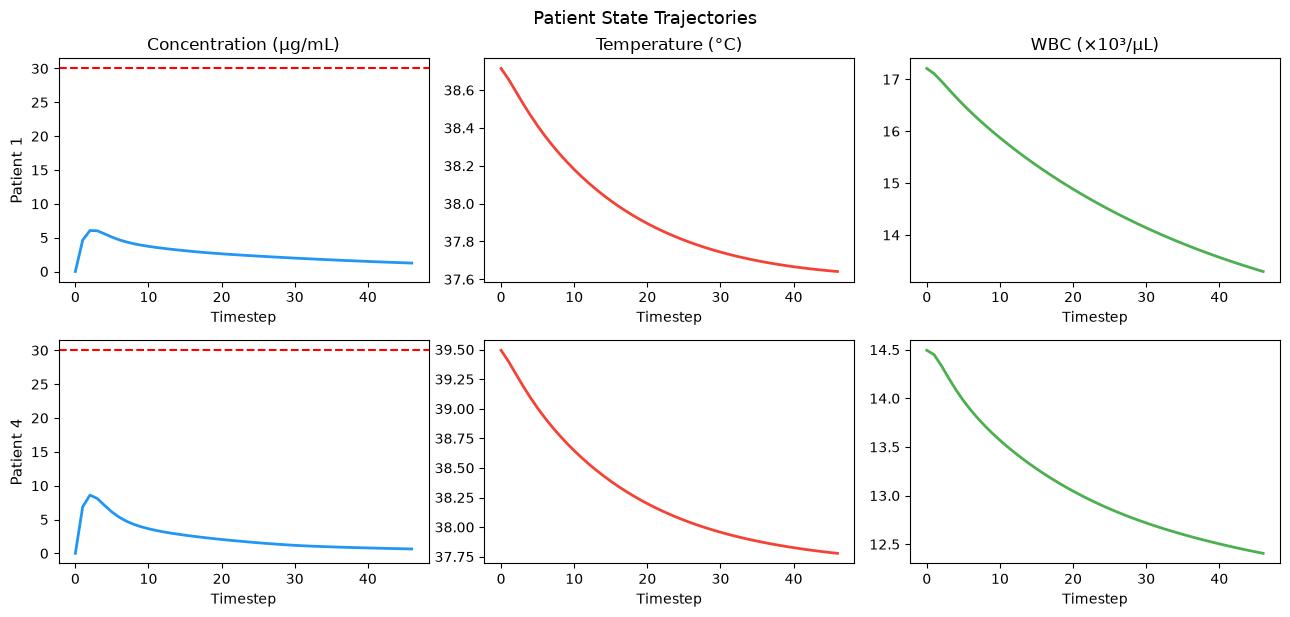

Total training samples: 2350  (50 patients × 47 timesteps)


In [4]:
# LIVE: Show patient trajectories
n_steps = cfg.timesteps - 1
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
feature_names = ['Concentration (µg/mL)', 'Temperature (°C)', 'WBC (×10³/µL)']
colours = ['#2196F3', '#F44336', '#4CAF50']

for row, patient_idx in enumerate([0, 3]):
    start = patient_idx * n_steps
    X_p = X[start:start + n_steps]
    for col in range(3):
        ax = axes[row, col]
        ax.plot(X_p[:, col], color=colours[col], lw=2)
        if col == 0:
            ax.axhline(30, color='red', ls='--', lw=1.5, label='C_safe')
            ax.set_ylabel(f'Patient {patient_idx+1}', fontsize=11)
        if row == 0:
            ax.set_title(feature_names[col])
        ax.set_xlabel('Timestep')

plt.tight_layout()
plt.suptitle('Patient State Trajectories', y=1.02, fontsize=13)
plt.show()
print(f'Total training samples: {X.shape[0]}  ({cfg.num_patients} patients × {n_steps} timesteps)')

---
## 2. Formalising Safety in Vehicle

Instead of a test set (finite), we write safety as a `forall` statement (infinite input space).

Vehicle compiles these properties into:
- **Differentiable losses** — for training
- **SMT queries** — for Marabou to prove no counterexample exists

### The spec — run this and walk through it

In [5]:
# LIVE: Show the Vehicle spec
with open('pk.vcl') as f:
    print(f.read())

### Talking points for the spec

- `@dataset` — marks scaler values that are inlined into the spec after training
- `@network pk` — binds the ONNX model at verification time
- `normpk` — normalises the input, then calls the network: `pk(normalise(x))`
- `safeInput` — defines the region we're making claims about (physical units, 5D box)
- `safeOutput` — applies the peak-concentration PK formula to the network's output
- `forall x` — this is the key: not a sample, but the *entire input box*

```vehicle
safe = forall x . safeInput x => safeOutput x
```

---
## 3. Baseline: MSE Training Fails Verification

Train a standard network. Then check it against the Vehicle loss — a positive loss means violations exist.

In [6]:
# LIVE: Train baseline
baseline_model = build_model(input_size=5)
baseline_history = train_model(
    baseline_model, X_train, y_train, X_test, y_test, epochs=15, batch_size=32
)
baseline_metrics = evaluate_model(baseline_model, X_test, y_test, y_scaler=y_scaler)
print(f"Baseline MAE: {baseline_metrics['mae']:.2f} mg")

Epoch 1/15


KeyboardInterrupt: 

In [ ]:
# LIVE: Check baseline model against the compiled Vehicle constraints
# constraint_fns was loaded in setup — no compilation delay here
baseline_net_fn = make_network_fn(baseline_model, y_mean, y_std)
baseline_safe = float(constraint_fns['safe'](pk=baseline_net_fn).numpy())

print('Baseline model — Vehicle constraint loss:')
print(f'  safe loss: {baseline_safe:.4f}  {"← VIOLATION" if baseline_safe > 0 else "OK"}')
print()
print('Low MSE does NOT imply formal safety.')


---
## 4. Property-Driven Training — Live Demo

### The loss scale problem

Before we train: why can't we just add the losses together with equal weight?

In [ ]:
# LIVE: Demonstrate the scale problem
fresh = build_model(input_size=5)
net_fn_raw = make_network_fn(fresh, y_mean, y_std)

X_b = tf.constant(X_train[:32], dtype=tf.float32)
y_b = tf.constant(y_train[:32], dtype=tf.float32)
task_l = float(tf.reduce_mean(tf.square(fresh(X_b, training=False) - y_b)).numpy())
safe_l  = float(constraint_fns['safe'](pk=net_fn_raw).numpy())

print('Loss magnitudes at init (y normalised, so task MSE ≈ 1):')
print(f'  Task (MSE):  {task_l:>8.3f}')
print(f'  safe:        {safe_l:>8.3f}   ← ~1000× task')
print()
print('GradNorm normalises each by its initial value → all start at 1.0')
print('Then adapts weights so each loss trains at the same rate.')


In [ ]:
# LIVE: Train with GradNorm (10 epochs for live demo — pre-computed result shown below)
pdt_model = build_model(input_size=5)

print('Two-phase training:')
print('  Phase 1 (epochs 1–3):  task only')
print('  Phase 2 (epochs 4–10): GradNorm balances task + safe')
print()

pdt_history = train_model_with_constraint(
    pdt_model, X_train, y_train, X_test, y_test,
    constraint_fn=constraint_fns['safe'],
    y_mean=y_mean, y_std=y_std,
    alpha=0.5, epochs=10, batch_size=32, phase_switch=3, verbose=True,
)


In [ ]:
# LIVE: Plot the adaptive weights
epochs_range = range(1, len(pdt_history['task_loss']) + 1)
phase_switch_epoch = 3

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Linear scale — constraint losses are 0 during phase 1, so log scale would break
ax = axes[0]
ax.plot(epochs_range, pdt_history['task_loss'],       label='Task', color='#2196F3', lw=2)
ax.plot(epochs_range, pdt_history['constraint_loss'], label='safe', color='#F44336', lw=2)
ax.axvline(phase_switch_epoch, color='gray', ls=':', lw=1.5, label='Phase switch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Per-task losses')
ax.legend()

ax2 = axes[1]
ax2.plot(epochs_range, pdt_history['task_weight'],       label='Task', color='#2196F3', lw=2)
ax2.plot(epochs_range, pdt_history['constraint_weight'], label='safe', color='#F44336', lw=2)
ax2.axvline(phase_switch_epoch, color='gray', ls=':', lw=1.5, label='Phase switch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('GradNorm weight')
ax2.set_title('Adaptive weights (GradNorm)')
ax2.legend()

plt.suptitle('GradNorm adapts weights so all tasks train at the same rate', fontsize=12)
plt.tight_layout()
plt.show()


---
## 5. Full Results — Pre-computed (100 epochs, phase-switch 20)

> These results come from the fully trained model on this branch (`rss`).  
> The 10-epoch live demo above will not fully converge — that is expected.

### Accuracy

| Metric | Baseline (MSE only) | PDT + GradNorm |
|--------|---------------------|----------------|
| MAE | 7.4 mg | **4.8 mg** |
| Max absolute error | 260 mg | **146 mg** |
| Corr(true, pred) | 0.989 | **0.996** |
| Pred std / True std | ~1.00 | 1.030 |
| Low-temp avg dose | — | 58.3 mg |
| High-temp avg dose | — | 259.5 mg |
| Responsiveness ratio | — | **4.45×** |

GradNorm improved accuracy by **35% MAE** and **44% max error** while preserving verification.

### Formal Verification (Vehicle 0.24.1 + Marabou)

```
Verifying properties:
  Ka_pos    [..] 0/0 queries  result: ✓ - (trivial)
  Ke_pos    [..] 0/0 queries  result: ✓ - (trivial)
  Ke_n_Ka   [..] 0/0 queries  result: ✓ - (trivial)
  Vd_pos    [..] 0/0 queries  result: ✓ - (trivial)
  C_safe_pos[..] 0/0 queries  result: ✓ - (trivial)
  ttd_pos   [..] 0/0 queries  result: ✓ - (trivial)
  safe      [==] 1/1 queries  result: ✓ - Marabou proved no counterexample exists
  nonNeg    [==] 1/1 queries  result: ✓ - Marabou proved no counterexample exists
```

**Marabou exhaustively searched the 5D input box and found no counterexample for any property.**

### What makes this different from good test accuracy?

The test set had 470 samples.  
`safe` quantifies over a *continuous* 5D box — infinitely many points.  
Marabou provides a proof, not a sample-based estimate.

In [ ]:
# LIVE: Check Vehicle losses on the live-trained model vs baseline
pdt_net_fn = make_network_fn(pdt_model, y_mean, y_std)
pdt_safe = float(constraint_fns['safe'](pk=pdt_net_fn).numpy())

print('Vehicle constraint losses — direction of travel after 10 epochs:')
print(f'  {"":10} {"Baseline":>10} {"PDT (10 ep)":>12}')
print(f'  {"safe loss":10} {baseline_safe:>10.4f} {pdt_safe:>12.4f}')
print()
print('More epochs → losses → 0 → Marabou finds no counterexample')


In [ ]:
# LIVE: Export model and run formal verification
import os, subprocess

os.makedirs('models', exist_ok=True)
export_onnx(pdt_model, out_path='models/pk_presentation.onnx')

params = C.DEFAULT_SPEC_PARAMS
param_args = []
for k, v in params.items():
    param_args += ['--parameter', f'{k}:{v}']

result = subprocess.run(
    ['vehicle', 'verify',
     '--spec', 'pk.vcl',
     '--network', 'pk:models/pk_presentation.onnx',
     '--verifier', 'Marabou'] + param_args,
    capture_output=True, text=True
)
print(result.stdout)
if result.stderr:
    print(result.stderr)


---
## 6. Key Engineering Decisions

### Why not just use a fixed weighting (e.g. 70% constraint, 30% task)?

You can — and it works (`trial/manual-pdt-training`).  
But GradNorm removes the hyperparameter search and improves accuracy:
- It adapts automatically as relative loss rates change during training
- The task doesn't get crowded out when constraint losses are initially large

### Why do we normalise y?

Without y normalisation, task MSE is ~25,000 mg² versus constraint ~1.0.  
GradNorm collapses task weight to near zero trying to balance.  
Normalising y brings task MSE to ~1.0, the same order as constraint losses.

### Why is the `safe` spec generated, not loaded directly?

`pk.vcl` has an `if Ka < Ke` branch on `@parameter` values.  
The Vehicle loss compiler can't resolve symbolic branches — it returns a constant.  
We inline Ka, Ke, Vd as literals in a generated temp `.vcl`, resolving the branch at compile time.

### Why reset the Adam optimiser at `phase_switch`?

Adam accumulated second-moment estimates calibrated to small task gradients.  
When constraint gradients (~1000× larger) first appear, effective step size = `lr / sqrt(v + ε)` is enormous.  
A fresh optimiser avoids this overshoot.

---
## Discussion Questions

1. **Robotics analogy:** Where in robotics would you apply Property-Driven Training?  
   (collision avoidance, joint torque limits, workspace constraints, stability certificates)

2. **Limitation:** We train with ke=0.1 but verify against Ke=3.5.  
   Why is the verification still sound? What does this assume?

3. **Scale:** Marabou is tractable here because the network is small (5→128→64→1).  
   What would you do for a larger network?  
   (abstraction refinement, input partitioning, probabilistic verification)

4. **Property completeness:** We verified `safe` and `nonNeg` but not every possible safety requirement.  
   How do you choose which properties to formalise?

---
## Student Notebook Link

Students can run the full tutorial themselves:  
**`colab_student.ipynb`** in the same repository — all cells run from scratch, ~20 min on CPU.

Exercises at the end:
1. Change `phase_switch` to 0 and observe collapse
2. Change `alpha` (GradNorm exponent) from 0.5 to 2.0
3. Increase `min_weight` from 0.05 to 0.5 — watch GradNorm stop rebalancing
4. Skip y-normalisation — see the scale problem directly
5. Add `nonNeg` as a training constraint